In [9]:
import pandas as pd
from pathlib import Path
from pyprojroot import here

SCANPY_DIR = 'data/scanpy/tmp/aegypti_reps_albopictus_reps_melanogaster_reps_japonicus_reps/'
SCANPY_DIR = here() / SCANPY_DIR

fp_metadata = SCANPY_DIR / 'protein_clusters_metadata.csv'
fp_enrichment = SCANPY_DIR / 'species_cluster_enrichment_fraction.csv'
fp_count = SCANPY_DIR / 'species_cluster_enrichment_count.csv'
fp_channels = SCANPY_DIR / 'channel_importance_rankings.csv'

metadata_df = pd.read_csv(fp_metadata)
counts_df = pd.read_csv(fp_count)

# Automatically identify species columns (any column except 'cluster')
species_columns = counts_df.select_dtypes(include='number').columns.difference(['cluster']).tolist()

# Sort counts_df based on the sum of all species columns
counts_df = counts_df.loc[counts_df[species_columns].sum(axis=1).sort_values(ascending=False).index]
enrichment_df = pd.read_csv(fp_enrichment)
channels_df = pd.read_csv(fp_channels)

print(f"\n[INFO] metadata_df - Scanpy cluster assignments ...........................\n{'-'*25}")
print(metadata_df.head(5))
print(f"\n[INFO] counts_df - Counts of species by cluster ...........................\n{'-'*25}")
print(counts_df.head())
print(f"\n[INFO] enrichment_df - Proportion of species by cluster ...................\n{'-'*25}")
print(enrichment_df.head(4))
print(f"\n[INFO] channels_df - ESMC Channel Markers .................................\n{'-'*25}")
print(channels_df.head(3))
print(f"{'.' * 80}")


[INFO] metadata_df - Scanpy cluster assignments ...........................
-------------------------
   protein_id  species  cluster
0  A0A6I8TNH2  aegypti        0
1  A0A6I8TNI3  aegypti        1
2  A0A6I8TNI9  aegypti        2
3  A0A6I8TNJ4  aegypti        3
4  A0A6I8TNJ6  aegypti        4

[INFO] counts_df - Counts of species by cluster ...........................
-------------------------
    cluster  aegypti  albopictus  japonicus  melanogaster
5         5      656         897       2814          1106
43       43     1191        1187       1111          1181
23       23     1039        1083       1172          1141
35       35       59         105       3732           220
0         0      882         983       1062          1083

[INFO] enrichment_df - Proportion of species by cluster ...................
-------------------------
   cluster    aegypti  albopictus  japonicus  melanogaster
0        0  21.995012   24.513716  26.483791     27.007481
1        1  24.469821   25.350734

In [10]:
############################################################################################
# TOP SIGNATURES (Fully Dynamic)
############################################################################################
THRESHOLD = 80
# Automatically extract lists of clusters for each species where the proportion exceeds the threshold
species_clusters = {
    species: enrichment_df.loc[enrichment_df[species] > THRESHOLD, 'cluster'].tolist()
    for species in species_columns
}
for species, clusters in species_clusters.items():
    print(f"{species}: {clusters}")
for species, clusters in species_clusters.items():
    print(f"\n[CLUSTERS] {species} {'.' * 30}")
    print(counts_df[counts_df['cluster'].isin(clusters)])

aegypti: [98]
albopictus: [83, 112, 120, 189, 190, 193, 194, 195, 196]
japonicus: [35]
melanogaster: [197, 198, 199, 200, 201, 202, 203]

[CLUSTERS] aegypti ..............................
    cluster  aegypti  albopictus  japonicus  melanogaster
98       98       49           1          0             3

[CLUSTERS] albopictus ..............................
     cluster  aegypti  albopictus  japonicus  melanogaster
83        83       42        1303         56            12
193      193        0        1018          2             0
120      120        3         951          1             0
112      112        1         230          0             0
189      189        1          23          0             0
190      190        1          15          0             0
196      196        0          11          0             0
194      194        0           7          0             0
195      195        0           6          0             0

[CLUSTERS] japonicus ..............................

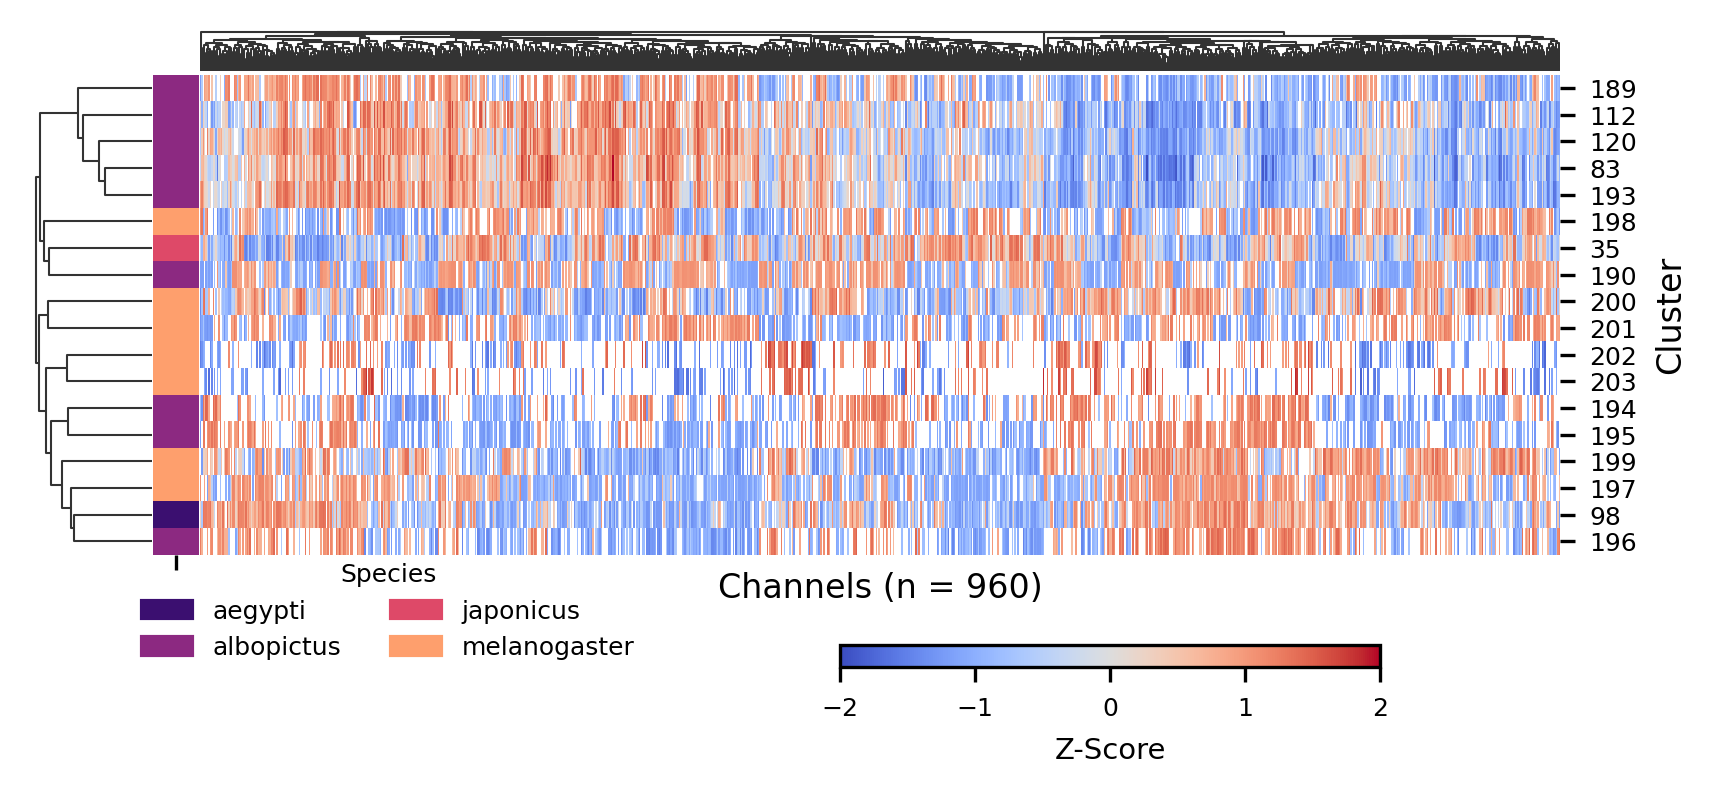

In [11]:
import warnings, numpy as np, pandas as pd, seaborn as sns
import matplotlib.pyplot as plt, matplotlib.patches as mpatches, matplotlib as mpl

# --- HARDCODED CONFIGURATION ---
BAN_SPECIES = []
FIGSIZE = (6, 2.5)
DPI = 300
CMAP_NAME = 'coolwarm'
Z_MIN, Z_MAX = -2, 2
PVAL_THRESHOLD = 0.05
MASK_COLOR = '#FFFFFF'
FALLBACK_COLOR = '#7f7f7f'
X_LABEL = 'Channels (n = 960)'
Y_LABEL = 'Cluster'
CBAR_LABEL = 'Z-Score'
SPECIES_TITLE = 'Species'
DENDROGRAM_RATIO = (0.08, 0.08)
PALETTE_NAME = 'magma'
# ------------------------------

warnings.filterwarnings('ignore', category=UserWarning)
allowed_clusters = [c for sp, cls in species_clusters.items() if sp not in BAN_SPECIES for c in cls]
df_subset = channels_df[channels_df['cluster'].isin(allowed_clusters)].copy()
pivot_scores = df_subset.pivot(index='cluster', columns='channel', values='score')
pivot_pvals = df_subset.pivot(index='cluster', columns='channel', values='pvals_adj')
mask = (pivot_pvals > PVAL_THRESHOLD) | pivot_pvals.isna()
valid_channels = ~mask.all(axis=0)
pivot_scores, mask = pivot_scores.loc[:, valid_channels], mask.loc[:, valid_channels]
norm_df = pivot_scores.sub(pivot_scores.mean(axis=1), axis=0).div(pivot_scores.std(axis=1).replace(0, 1), axis=0).fillna(0)
unique_species = [sp for sp in species_clusters.keys() if sp not in BAN_SPECIES]
palette = sns.color_palette(PALETTE_NAME, len(unique_species))
species_palette = {sp: palette[i] for i, sp in enumerate(unique_species)}
cluster_to_species = {c: sp for sp, cls in species_clusters.items() if sp not in BAN_SPECIES for c in cls}
row_colors = pd.Series([species_palette.get(cluster_to_species.get(c, ''), FALLBACK_COLOR) for c in norm_df.index], index=norm_df.index)
cmap = mpl.colormaps[CMAP_NAME].copy(); cmap.set_bad(MASK_COLOR)
g = sns.clustermap(norm_df, mask=mask, cmap=cmap, center=0, figsize=FIGSIZE, col_cluster=True, row_cluster=True, row_colors=row_colors, xticklabels=False, yticklabels=True, dendrogram_ratio=DENDROGRAM_RATIO)
if g.ax_cbar is not None: g.ax_cbar.remove()
g.ax_heatmap.set_xlabel(X_LABEL, fontsize=8); g.ax_heatmap.set_ylabel(Y_LABEL, fontsize=8); g.ax_heatmap.tick_params(labelsize=6)
g.fig.subplots_adjust(bottom=0.20, top=0.90, left=0.1, right=0.95)
handles = [mpatches.Patch(color=col, label=sp) for sp, col in species_palette.items()]
g.fig.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.15, 0.03), ncol=2, fontsize=6, frameon=False, title=SPECIES_TITLE, title_fontsize=6)
cax = g.fig.add_axes([0.55, 0.05, 0.30, 0.03]); norm = mpl.colors.Normalize(vmin=Z_MIN, vmax=Z_MAX); sm = mpl.cm.ScalarMappable(cmap=CMAP_NAME, norm=norm); sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cax, orientation='horizontal'); cbar.set_label(CBAR_LABEL, fontsize=7); cbar.ax.tick_params(labelsize=6)
g.fig.set_dpi(DPI); plt.show()